In [ ]:
!pip install scikeras
!pip install scikit-learn==1.5.2

In [ ]:
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.utils import to_categorical

from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)
from scikeras.wrappers import KerasClassifier

from google.colab import files

np.random.seed(42)
tf.random.set_seed(42)

CLASS_NAMES = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

In [ ]:

def save_plot(filename):

    path = f"{filename}.eps"
    plt.savefig(path, format='eps', dpi=600, bbox_inches='tight')
    files.download(path)
    print(f"Saved and downloaded: {path}")


In [ ]:
(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

print(f"Train images shape : {x_train.shape}")
print(f"Train labels shape : {y_train.shape}")
print(f"Test images shape  : {x_test.shape}")
print(f"Test labels shape  : {y_test.shape}")

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train images shape : (60000, 28, 28)
Train labels shape : (60000,)
Test images shape  : (10000, 28, 28)
Test labels shape  : (10000,)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Saved and downloaded: plot1_sample_images.eps


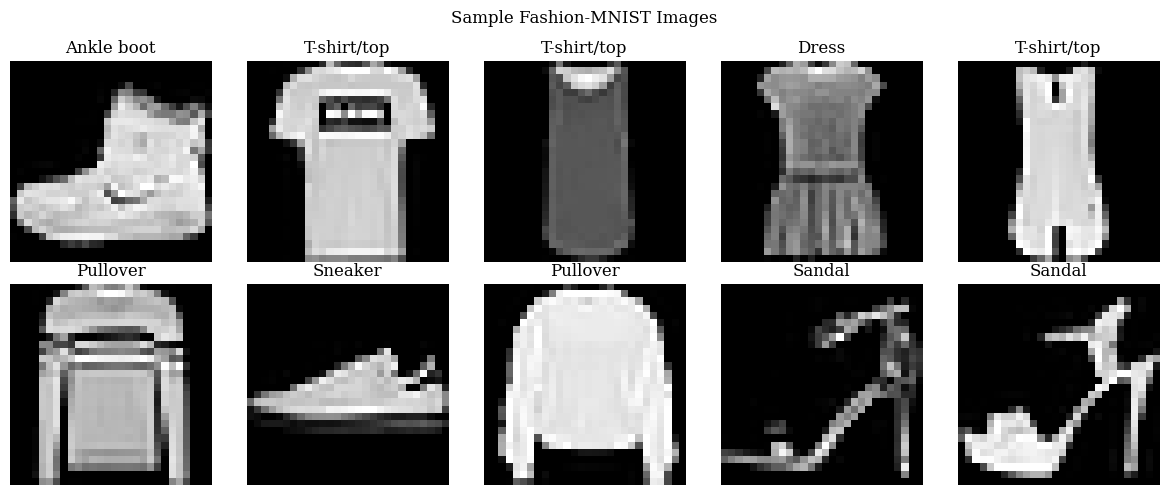

In [ ]:
def plot_sample_images(images, labels, class_names, n=10):
    plt.figure(figsize=(12, 5))
    for i in range(n):
        plt.subplot(2, 5, i + 1)
        plt.imshow(images[i], cmap='gray')
        plt.title(class_names[labels[i]])
        plt.axis('off')
    plt.suptitle("Sample Fashion-MNIST Images")
    plt.tight_layout()
    save_plot("plot1_sample_images")
    plt.show()

plot_sample_images(x_train, y_train, CLASS_NAMES, n=10)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Saved and downloaded: plot2_class_distribution.eps


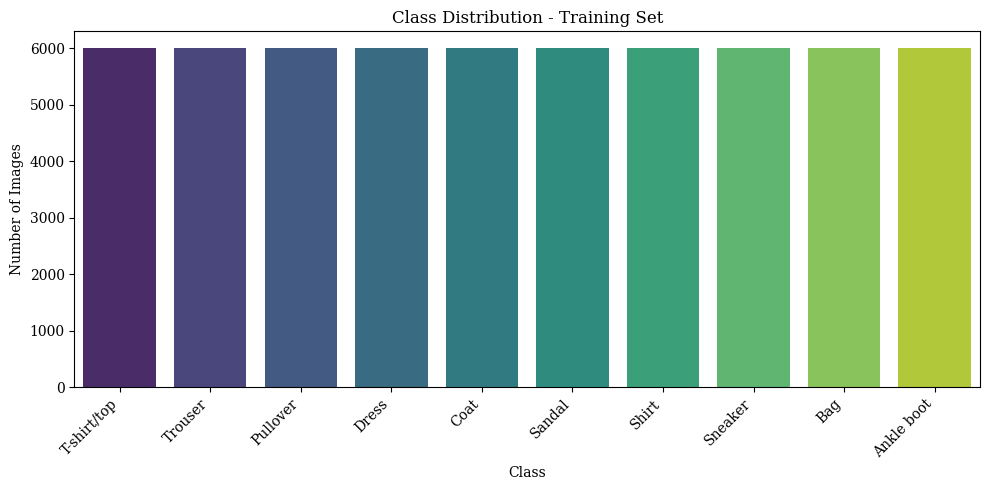

In [ ]:
def plot_class_distribution(labels, class_names):
    unique, counts = np.unique(labels, return_counts=True)
    plt.figure(figsize=(10, 5))
    sns.barplot(x=[class_names[u] for u in unique], y=counts, hue=[class_names[u] for u in unique],
                palette='viridis', legend=False)
    plt.title("Class Distribution - Training Set")
    plt.xlabel("Class")
    plt.ylabel("Number of Images")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    save_plot("plot2_class_distribution")
    plt.show()

plot_class_distribution(y_train, CLASS_NAMES)

In [ ]:
print(f"\nBefore flattening: {x_train.shape}, {x_test.shape}")
x_train_flat = x_train.reshape(x_train.shape[0], -1)
x_test_flat = x_test.reshape(x_test.shape[0], -1)
print(f"After flattening : {x_train_flat.shape}, {x_test_flat.shape}")

# 4. Normalize pixels to [0, 1]
x_train_norm = x_train_flat.astype('float32') / 255.0
x_test_norm = x_test_flat.astype('float32') / 255.0
print(f"Pixel range after normalization: [{x_train_norm.min()}, {x_train_norm.max()}]")

# 5. Convert labels into one-hot vectors
y_train_oh = to_categorical(y_train, num_classes=10)
y_test_oh = to_categorical(y_test, num_classes=10)
print(f"One-hot label shape: {y_train_oh.shape}")


Before flattening: (60000, 28, 28), (10000, 28, 28)
After flattening : (60000, 784), (10000, 784)
Pixel range after normalization: [0.0, 1.0]
One-hot label shape: (60000, 10)


In [ ]:
#Task 1
print("\n--- Task 1: Dataset Exploration ---")
print(f"Training images: {x_train.shape[0]}, Testing images: {x_test.shape[0]}")
print(f"Image size: {x_train.shape[1]}x{x_train.shape[2]}, Classes: {len(CLASS_NAMES)}")


--- Task 1: Dataset Exploration ---
Training images: 60000, Testing images: 10000
Image size: 28x28, Classes: 10


In [ ]:
print("\n--- Task 2: Data Preprocessing ---")
print(f"Before preprocessing - X_train: {x_train.shape}, y_train: {y_train.shape}")
print(f"After preprocessing  - X_train: {x_train_norm.shape}, y_train: {y_train_oh.shape}")


--- Task 2: Data Preprocessing ---
Before preprocessing - X_train: (60000, 28, 28), y_train: (60000,)
After preprocessing  - X_train: (60000, 784), y_train: (60000, 10)


In [ ]:
#Task 3
def build_baseline_model():
    model = keras.Sequential([
        layers.Input(shape=(784,)),
        layers.Dense(128, activation='relu'),
        layers.Dense(64, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])
    model.compile(optimizer='adam',
                   loss='categorical_crossentropy',
                   metrics=['accuracy'])
    return model

baseline_model = build_baseline_model()
baseline_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#Task 4
print("\n--- Task 4: Model Training ---")
start_time = time.time()
history = baseline_model.fit(
    x_train_norm, y_train_oh,
    validation_split=0.1,
    epochs=20,
    batch_size=32,
    verbose=2
)
baseline_train_time = time.time() - start_time
print(f"Baseline training time: {baseline_train_time:.2f} seconds")


--- Task 4: Model Training ---
Epoch 1/20
1688/1688 - 13s - 8ms/step - accuracy: 0.8207 - loss: 0.5026 - val_accuracy: 0.8470 - val_loss: 0.4115
Epoch 2/20
1688/1688 - 14s - 8ms/step - accuracy: 0.8647 - loss: 0.3724 - val_accuracy: 0.8597 - val_loss: 0.3775
Epoch 3/20
1688/1688 - 4s - 3ms/step - accuracy: 0.8769 - loss: 0.3357 - val_accuracy: 0.8613 - val_loss: 0.3748
Epoch 4/20
1688/1688 - 4s - 3ms/step - accuracy: 0.8847 - loss: 0.3108 - val_accuracy: 0.8680 - val_loss: 0.3656
Epoch 5/20
1688/1688 - 5s - 3ms/step - accuracy: 0.8928 - loss: 0.2904 - val_accuracy: 0.8682 - val_loss: 0.3612
Epoch 6/20
1688/1688 - 4s - 3ms/step - accuracy: 0.8977 - loss: 0.2744 - val_accuracy: 0.8698 - val_loss: 0.3605
Epoch 7/20
1688/1688 - 4s - 3ms/step - accuracy: 0.9039 - loss: 0.2593 - val_accuracy: 0.8728 - val_loss: 0.3728
Epoch 8/20
1688/1688 - 5s - 3ms/step - accuracy: 0.9059 - loss: 0.2486 - val_accuracy: 0.8775 - val_loss: 0.3608
Epoch 9/20
1688/1688 - 5s - 3ms/step - accuracy: 0.9106 - loss

In [ ]:
#Task 5
# ---- Task 5: Model Evaluation ----
print("\n--- Task 5: Model Evaluation ---")

def evaluate_model(model, x_test, y_test_oh, y_test_labels, model_name="Model"):
    y_pred_probs = model.predict(x_test)
    y_pred = np.argmax(y_pred_probs, axis=1)

    acc = accuracy_score(y_test_labels, y_pred)
    prec = precision_score(y_test_labels, y_pred, average='weighted')
    rec = recall_score(y_test_labels, y_pred, average='weighted')
    f1 = f1_score(y_test_labels, y_pred, average='weighted')
    cm = confusion_matrix(y_test_labels, y_pred)
    report = classification_report(y_test_labels, y_pred, target_names=CLASS_NAMES)

    print(f"\n{model_name} Evaluation:")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-score : {f1:.4f}")
    print("\nClassification Report:\n", report)

    return {
        'accuracy': acc, 'precision': prec, 'recall': rec,
        'f1': f1, 'confusion_matrix': cm, 'y_pred': y_pred
    }

baseline_results = evaluate_model(baseline_model, x_test_norm, y_test_oh, y_test, "Baseline MLP")


--- Task 5: Model Evaluation ---
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

Baseline MLP Evaluation:
Accuracy : 0.8796
Precision: 0.8811
Recall   : 0.8796
F1-score : 0.8771

Classification Report:
               precision    recall  f1-score   support

 T-shirt/top       0.79      0.87      0.83      1000
     Trouser       0.99      0.96      0.98      1000
    Pullover       0.75      0.84      0.80      1000
       Dress       0.82      0.93      0.87      1000
        Coat       0.80      0.81      0.80      1000
      Sandal       0.97      0.97      0.97      1000
       Shirt       0.80      0.55      0.65      1000
     Sneaker       0.93      0.97      0.95      1000
         Bag       0.98      0.96      0.97      1000
  Ankle boot       0.98      0.93      0.95      1000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Saved and downloaded: plot3_training_accuracy.eps


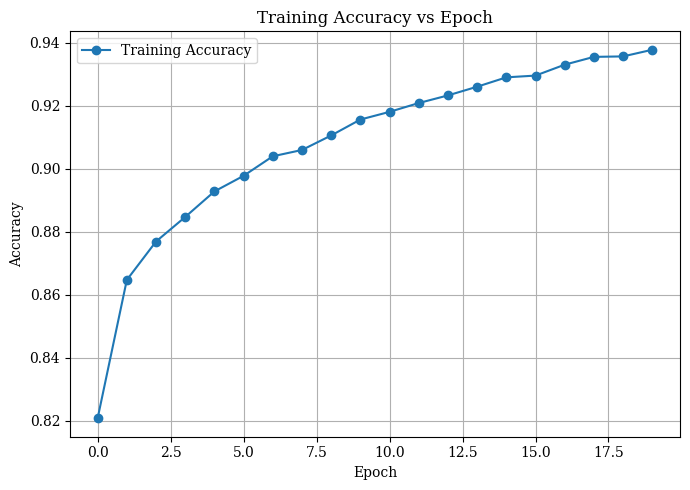

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Saved and downloaded: plot4_validation_accuracy.eps


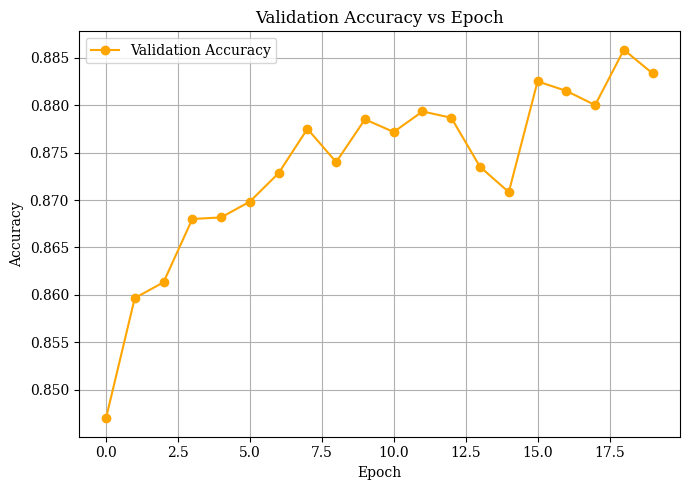

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Saved and downloaded: plot5_training_loss.eps


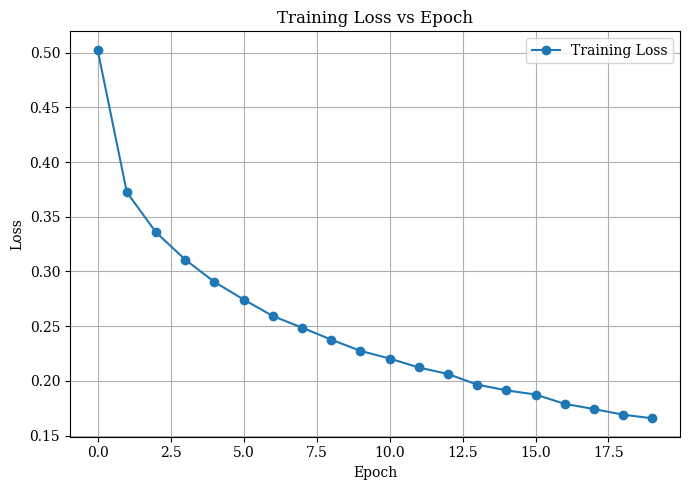

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Saved and downloaded: plot6_validation_loss.eps


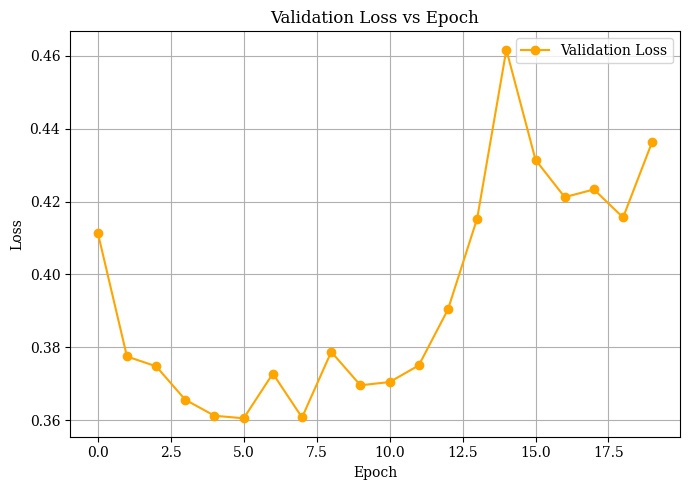

In [ ]:
def plot_training_curves(history):
    # Plot 3: Training Accuracy vs Epoch
    plt.figure(figsize=(7, 5))
    plt.plot(history.history['accuracy'], label='Training Accuracy', marker='o')
    plt.title("Training Accuracy vs Epoch")
    plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.legend(); plt.grid(True)
    plt.tight_layout();
    save_plot("plot3_training_accuracy")
    plt.show()

    # Plot 4: Validation Accuracy vs Epoch
    plt.figure(figsize=(7, 5))
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy',
              color='orange', marker='o')
    plt.title("Validation Accuracy vs Epoch")
    plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.legend(); plt.grid(True)
    plt.tight_layout()
    save_plot("plot4_validation_accuracy")
    plt.show()

    # Plot 5: Training Loss vs Epoch
    plt.figure(figsize=(7, 5))
    plt.plot(history.history['loss'], label='Training Loss', marker='o')
    plt.title("Training Loss vs Epoch")
    plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.legend(); plt.grid(True)
    plt.tight_layout()
    save_plot("plot5_training_loss")
    plt.show()

    # Plot 6: Validation Loss vs Epoch
    plt.figure(figsize=(7, 5))
    plt.plot(history.history['val_loss'], label='Validation Loss',
              color='orange', marker='o')
    plt.title("Validation Loss vs Epoch")
    plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.legend(); plt.grid(True)
    plt.tight_layout()
    save_plot("plot6_validation_loss")
    plt.show()

plot_training_curves(history)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Saved and downloaded: plot7_confusion_matrix_baseline.eps


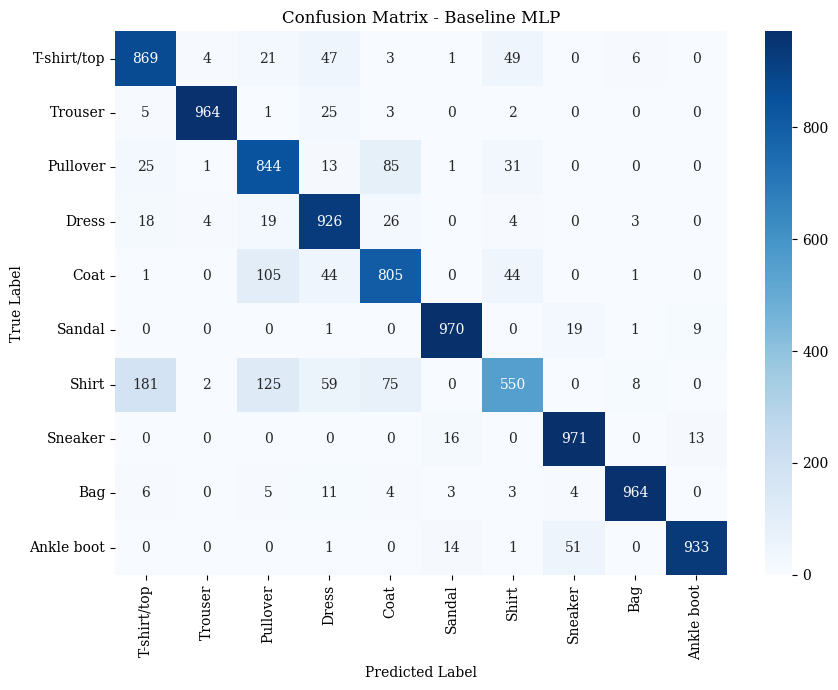

In [ ]:
def plot_confusion_matrix(cm, class_names, title="Confusion Matrix", filename="plot7_confusion_matrix"):
    plt.figure(figsize=(9, 7))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(title)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.tight_layout()
    save_plot(filename)
    plt.show()

plot_confusion_matrix(baseline_results['confusion_matrix'], CLASS_NAMES,
                       title="Confusion Matrix - Baseline MLP",
                       filename="plot7_confusion_matrix_baseline")

In [ ]:
#Task 6 (helper): Tunable Model Builder
def build_tunable_model(hidden_layers=2, hidden_neurons=128, activation="relu",
                         dropout_rate=0.0, optimizer_name="adam", learning_rate=0.001):
    model = keras.Sequential()
    model.add(layers.Input(shape=(784,)))

    for _ in range(hidden_layers):
        model.add(layers.Dense(hidden_neurons, activation=activation))
        if dropout_rate > 0.0:
            model.add(layers.Dropout(dropout_rate))

    model.add(layers.Dense(10, activation='softmax'))

    if optimizer_name == "adam":
        optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
    elif optimizer_name == "sgd":
        optimizer = keras.optimizers.SGD(learning_rate=learning_rate)
    elif optimizer_name == "rmsprop":
        optimizer = keras.optimizers.RMSprop(learning_rate=learning_rate)
    else:
        raise ValueError(f"Unknown optimizer_name: {optimizer_name}")

    model.compile(optimizer=optimizer,
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

In [ ]:
clf = KerasClassifier(
    model=build_tunable_model,
    verbose=0,
    hidden_layers=1,
    hidden_neurons=64,
    learning_rate=0.001,
    activation='relu',
    dropout_rate=0.0,
    optimizer_name='adam',
    epochs=10,
    batch_size=32,
    loss='categorical_crossentropy',
)

# Full search space as specified in the manual
param_dist = {
    'model__hidden_layers': [1, 2, 3],
    'model__hidden_neurons': [32, 64, 128, 256],
    'model__learning_rate': [0.1, 0.01, 0.001],
    'batch_size': [16, 32, 64, 128],
    'epochs': [10, 20, 30],
    'model__optimizer_name': ['sgd', 'adam', 'rmsprop'],
    'model__activation': ['relu', 'tanh', 'sigmoid'],
    'model__dropout_rate': [0.0, 0.2, 0.5],
}


In [ ]:
import numpy as np
# Variables for Hyperparameter Search
N_ITER = 10
CV_FOLDS = 5
SEARCH_SAMPLE_SIZE = 6000

rng = np.random.default_rng(42)
search_idx = rng.choice(len(x_train_norm), size=SEARCH_SAMPLE_SIZE, replace=False)
x_search = x_train_norm[search_idx]
y_search = y_train_oh[search_idx]

#Task 6: Hyperparameter Search
search = RandomizedSearchCV(
    estimator=clf,
    param_distributions=param_dist,
    n_iter=N_ITER,
    cv=CV_FOLDS,
    random_state=42,
    n_jobs=1,
    verbose=2,
)

print(f"running randomized search: {N_ITER} candidates x {CV_FOLDS} folds = {N_ITER * CV_FOLDS} model fits")
print(f"search subsample size: {SEARCH_SAMPLE_SIZE} of {len(x_train_norm)} training images\n")

search.fit(x_search, y_search)

print("\nbest hyperparameters found:")
for key, value in search.best_params_.items():
    print(f"  {key}: {value}")
print(f"best cross validation accuracy: {search.best_score_:.4f}")

# -----------------------------------------------------------------------
# Inspect how much each hyperparameter affected the search
# -----------------------------------------------------------------------
results_df = pd.DataFrame(search.cv_results_)

print("\nmean cv accuracy by hyperparameter value (within the sampled candidates):")
for param in param_dist.keys():
    col = f"param_{param}"
    if col in results_df.columns:
        grouped = results_df.groupby(col)["mean_test_score"].mean().sort_values(ascending=False)
        print(f"\n{param}:")
        print(grouped.to_string())

results_df.to_csv("hyperparameter_search_cv_results.csv", index=False)
files.download("hyperparameter_search_cv_results.csv")

running randomized search: 10 candidates x 5 folds = 50 model fits
search subsample size: 6000 of 60000 training images

Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV] END batch_size=64, epochs=20, model__activation=tanh, model__dropout_rate=0.2, model__hidden_layers=1, model__hidden_neurons=256, model__learning_rate=0.001, model__optimizer_name=adam; total time=  10.5s
[CV] END batch_size=64, epochs=20, model__activation=tanh, model__dropout_rate=0.2, model__hidden_layers=1, model__hidden_neurons=256, model__learning_rate=0.001, model__optimizer_name=adam; total time=   6.3s
[CV] END batch_size=64, epochs=20, model__activation=tanh, model__dropout_rate=0.2, model__hidden_layers=1, model__hidden_neurons=256, model__learning_rate=0.001, model__optimizer_name=adam; total time=   7.2s
[CV] END batch_size=64, epochs=20, model__activation=tanh, model__dropout_rate=0.2, model__hidden_layers=1, model__hidden_neurons=256, model__learning_rate=0.001, model__optimizer_name=ada

/usr/local/lib/python3.12/dist-packages/numpy/ma/core.py:2846: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,



best hyperparameters found:
  model__optimizer_name: adam
  model__learning_rate: 0.001
  model__hidden_neurons: 256
  model__hidden_layers: 2
  model__dropout_rate: 0.0
  model__activation: sigmoid
  epochs: 30
  batch_size: 32
best cross validation accuracy: 0.8443

mean cv accuracy by hyperparameter value (within the sampled candidates):

model__hidden_layers:
param_model__hidden_layers
2    0.835917
3    0.811444
1    0.726133

model__hidden_neurons:
param_model__hidden_neurons
128    0.828667
256    0.823867
32     0.710333
64     0.684083

model__learning_rate:
param_model__learning_rate
0.001    0.835286
0.010    0.768667
0.100    0.560583

batch_size:
param_batch_size
128    0.827500
16     0.798417
32     0.778167
64     0.710833

epochs:
param_epochs
20    0.839083
30    0.776267
10    0.725778

model__optimizer_name:
param_model__optimizer_name
rmsprop    0.798667
adam       0.767437

model__activation:
param_model__activation
tanh       0.797595
sigmoid    0.717889

model_

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
#Task 7: Retrain Optimized Model on Full Training Set
best_params = search.best_params_

optimized_model = build_tunable_model(
    hidden_layers=best_params["model__hidden_layers"],
    hidden_neurons=best_params["model__hidden_neurons"],
    activation=best_params["model__activation"],
    dropout_rate=best_params["model__dropout_rate"],
    optimizer_name=best_params["model__optimizer_name"],
    learning_rate=best_params["model__learning_rate"],
)

start_time = time.time()
optimized_model.fit(
    x_train_norm, y_train_oh,
    epochs=best_params["epochs"],
    batch_size=best_params["batch_size"],
    verbose=2,
)
optimized_train_time = time.time() - start_time
print(f"Optimized model training time: {optimized_train_time:.2f} seconds")

Epoch 1/30
1875/1875 - 6s - 3ms/step - accuracy: 0.8083 - loss: 0.5358
Epoch 2/30
1875/1875 - 5s - 3ms/step - accuracy: 0.8631 - loss: 0.3795
Epoch 3/30
1875/1875 - 5s - 2ms/step - accuracy: 0.8748 - loss: 0.3414
Epoch 4/30
1875/1875 - 6s - 3ms/step - accuracy: 0.8841 - loss: 0.3148
Epoch 5/30
1875/1875 - 4s - 2ms/step - accuracy: 0.8907 - loss: 0.2937
Epoch 6/30
1875/1875 - 4s - 2ms/step - accuracy: 0.8971 - loss: 0.2761
Epoch 7/30
1875/1875 - 5s - 3ms/step - accuracy: 0.9029 - loss: 0.2607
Epoch 8/30
1875/1875 - 4s - 2ms/step - accuracy: 0.9073 - loss: 0.2468
Epoch 9/30
1875/1875 - 5s - 3ms/step - accuracy: 0.9115 - loss: 0.2342
Epoch 10/30
1875/1875 - 5s - 3ms/step - accuracy: 0.9165 - loss: 0.2221
Epoch 11/30
1875/1875 - 5s - 2ms/step - accuracy: 0.9205 - loss: 0.2113
Epoch 12/30
1875/1875 - 5s - 3ms/step - accuracy: 0.9246 - loss: 0.2009
Epoch 13/30
1875/1875 - 4s - 2ms/step - accuracy: 0.9281 - loss: 0.1912
Epoch 14/30
1875/1875 - 5s - 2ms/step - accuracy: 0.9321 - loss: 0.1818
E

Evaluating Optimized Model
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

Optimized MLP Evaluation:
Accuracy : 0.8824
Precision: 0.8834
Recall   : 0.8824
F1-score : 0.8822

Classification Report:
               precision    recall  f1-score   support

 T-shirt/top       0.84      0.84      0.84      1000
     Trouser       0.98      0.98      0.98      1000
    Pullover       0.82      0.80      0.81      1000
       Dress       0.85      0.91      0.88      1000
        Coat       0.80      0.82      0.81      1000
      Sandal       0.99      0.92      0.95      1000
       Shirt       0.73      0.69      0.71      1000
     Sneaker       0.88      0.99      0.93      1000
         Bag       0.98      0.96      0.97      1000
  Ankle boot       0.97      0.91      0.94      1000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Saved and downloaded: plot8_confusion_matrix_optimized.eps


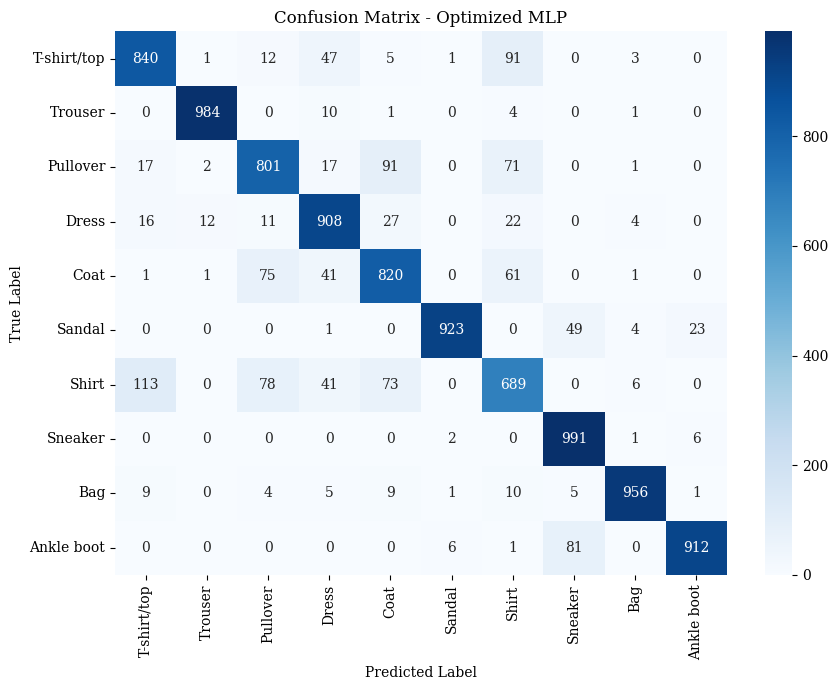

In [ ]:
print("Evaluating Optimized Model")
optimized_results = evaluate_model(optimized_model, x_test_norm, y_test_oh, y_test, "Optimized MLP")

# Plot 8: Confusion Matrix for the Optimized Model
plot_confusion_matrix(optimized_results['confusion_matrix'], CLASS_NAMES,
                       title="Confusion Matrix - Optimized MLP",
                       filename="plot8_confusion_matrix_optimized")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Saved and downloaded: plot9_hyperparameter_search_results.eps


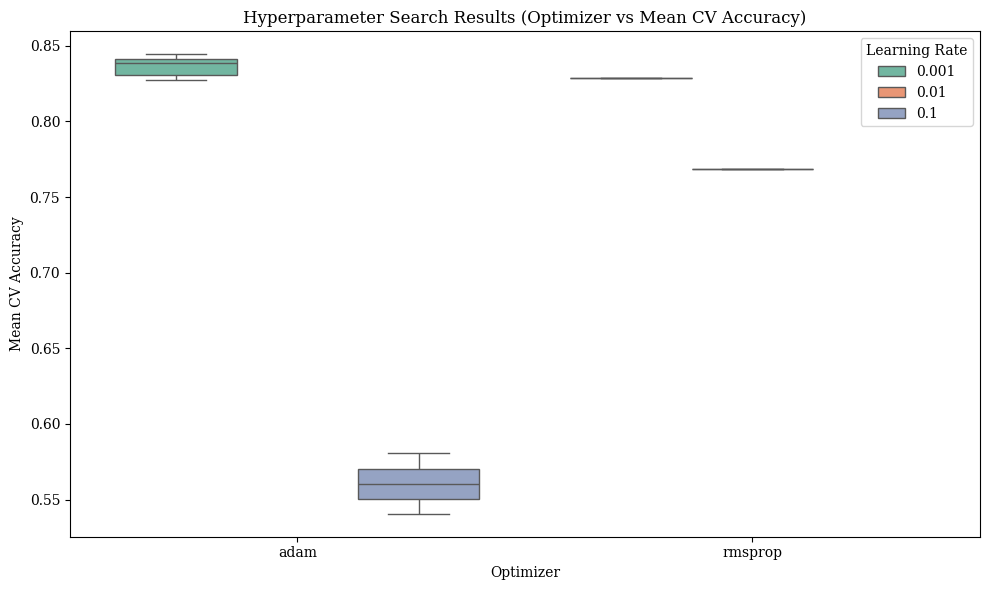

In [ ]:
# ---- Plot 9: Hyperparameter Search Results ----
def plot_hyperparameter_results(results_df):
    plt.figure(figsize=(10, 6))

    # Plotting Optimizer vs Mean Test Score, categorized by Learning Rate
    sns.boxplot(data=results_df, x='param_model__optimizer_name', y='mean_test_score', hue='param_model__learning_rate', palette='Set2')

    plt.title("Hyperparameter Search Results (Optimizer vs Mean CV Accuracy)")
    plt.xlabel("Optimizer")
    plt.ylabel("Mean CV Accuracy")
    plt.legend(title='Learning Rate')
    plt.tight_layout()

    save_plot("plot9_hyperparameter_search_results")
    plt.show()

plot_hyperparameter_results(results_df)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Saved and downloaded: plot10_model_comparison.eps


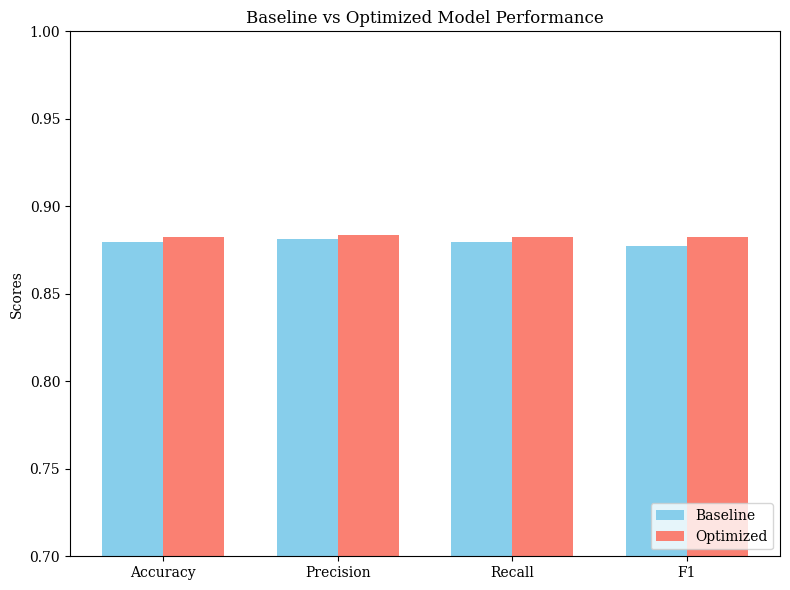

In [ ]:
# ---- Plot 10: Best Model Accuracy Comparison
def plot_model_comparison(baseline_res, optimized_res):
    metrics = ['accuracy', 'precision', 'recall', 'f1']
    baseline_scores = [baseline_res[m] for m in metrics]
    optimized_scores = [optimized_res[m] for m in metrics]

    x = np.arange(len(metrics))
    width = 0.35

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.bar(x - width/2, baseline_scores, width, label='Baseline', color='skyblue')
    ax.bar(x + width/2, optimized_scores, width, label='Optimized', color='salmon')

    ax.set_ylabel('Scores')
    ax.set_title('Baseline vs Optimized Model Performance')
    ax.set_xticks(x)
    ax.set_xticklabels([m.capitalize() for m in metrics])
    ax.legend(loc='lower right')
    ax.set_ylim([0.7, 1.0]) # Set y-limit to highlight differences

    plt.tight_layout()
    save_plot("plot10_model_comparison")
    plt.show()

plot_model_comparison(baseline_results, optimized_results)

In [ ]:

print("\\n" + "="*40)
print("             9. RESULTS")
print("="*40)

print("\\nBest Hyperparameters:")
print(f"Hidden Layers        : {best_params['model__hidden_layers']}")
print(f"Hidden Neurons       : {best_params['model__hidden_neurons']}")
print(f"Learning Rate        : {best_params['model__learning_rate']}")
print(f"Batch Size           : {best_params['batch_size']}")
print(f"Optimizer            : {best_params['model__optimizer_name']}")
print(f"Activation Function  : {best_params['model__activation']}")
print(f"Epochs               : {best_params['epochs']}")
print(f"Dropout              : {best_params['model__dropout_rate']}")
print(f"Cross-validation Acc : {search.best_score_:.4f}")
print(f"Testing Accuracy     : {optimized_results['accuracy']:.4f}")

print("\\nPerformance Comparison:")
print(f"{'Metric':<15} | {'Baseline':<10} | {'Optimized':<10}")
print("-" * 45)
print(f"{'Accuracy':<15} | {baseline_results['accuracy']:.4f}     | {optimized_results['accuracy']:.4f}")
print(f"{'Precision':<15} | {baseline_results['precision']:.4f}     | {optimized_results['precision']:.4f}")
print(f"{'Recall':<15} | {baseline_results['recall']:.4f}     | {optimized_results['recall']:.4f}")
print(f"{'F1-score':<15} | {baseline_results['f1']:.4f}     | {optimized_results['f1']:.4f}")
print(f"{'Training Time':<15} | {baseline_train_time:.2f}s   | {optimized_train_time:.2f}s")
print("="*45)

\n========================================
             9. RESULTS
\nBest Hyperparameters:
Hidden Layers        : 2
Hidden Neurons       : 256
Learning Rate        : 0.001
Batch Size           : 32
Optimizer            : adam
Activation Function  : sigmoid
Epochs               : 30
Dropout              : 0.0
Cross-validation Acc : 0.8443
Testing Accuracy     : 0.8824
\nPerformance Comparison:
Metric          | Baseline   | Optimized 
---------------------------------------------
Accuracy        | 0.8796     | 0.8824
Precision       | 0.8811     | 0.8834
Recall          | 0.8796     | 0.8824
F1-score        | 0.8771     | 0.8822
Training Time   | 110.90s   | 153.87s
